In [1]:
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from datetime import datetime

import src.process_dfs as process_dfs
import src.constants as c
from src.data_cleaning.general import filter_df

In [2]:
aberdeen_ascat_df, aberdeen_era5_df = process_dfs.main(c.ABERDEEN_NAME, c.CLEANED_DATA_PATH)

aberdeen_ascat_df.head()

,backscatter40,swath_indicator,as_des_pass,sat_id,soil_temp,class
UTC_timestamp,,,,,,
2009-10-28 16:00:00+00:00,-11.604655,1,1,3,5.7,thawed
2009-10-29 17:00:00+00:00,-11.543498,0,1,3,5.7,thawed
2009-10-30 03:00:00+00:00,-11.682631,0,0,3,5.3,thawed
2009-10-31 04:00:00+00:00,-14.228068,1,0,3,4.2,thawed
2009-11-01 04:00:00+00:00,-12.675194,1,0,3,4.5,thawed


In [3]:
labels = ['frozen', 'transition', 'thawed']
cm = confusion_matrix(aberdeen_era5_df['class'], aberdeen_era5_df['pred'], labels=labels)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print(df_cm)

            frozen  transition  thawed
frozen        2006         327      91
transition    1570         831     429
thawed         363         355    8798


<Axes: xlabel='date', ylabel='stl1'>

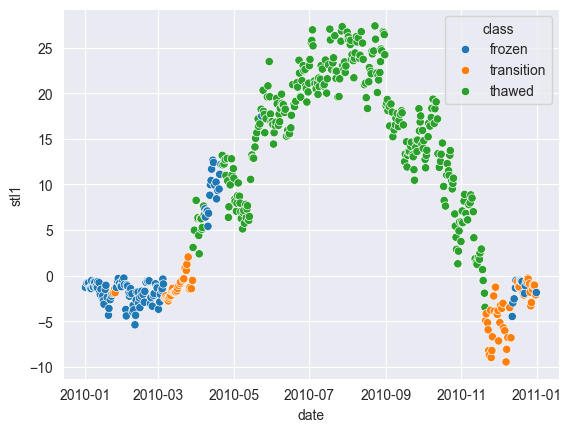

In [4]:
temp = aberdeen_era5_df.assign(date=aberdeen_era5_df.index)
temp = filter_df(temp, [datetime(2010, 1, 1), datetime(2011, 1, 1)])
sns.scatterplot(data=temp, x='date', y='stl1', hue='class')